# Preparation

In [1]:
# %matplotlib widget
# %config InlineBackend.figure_format = 'svg'

import os, math
from enum import IntEnum, auto
from collections import defaultdict, namedtuple, Counter, deque
from dataclasses import dataclass
from heapq import heapify, heappush, heappop
import itertools
import sqlite3
import pickle
import datetime
import queue
import json
import copy
from IPython.core.getipython import get_ipython

from PIL import Image, ImageDraw
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import scipy as sp
import numpy as np
import cupy as cp
import pandas as pd
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('../../lib')

from utils import *
from shared_types import SensorInstance

In [2]:
LOG = Logging()

config_var = 'SQLITE3_SEQ_GRID_0_2_4096'
config = Config(config_var)
# RNG = np.random.default_rng() 
RNG = np.random.default_rng(42)

if cp.cuda.is_available():
    xp = cp.get_array_module(cp.empty(1))
    xp_array_from_gpu = lambda a: a.get() if isinstance(a, cp.ndarray) else a
    xp_array_to_gpu = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
    xp_array_to_gpu_copy = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
else:
    xp = cp.get_array_module(np.empty(1))
    xp_array_from_gpu = lambda a: a
    xp_array_to_gpu = lambda a: a
    xp_array_to_gpu_copy = lambda a: a.copy()

print(f'xp={xp.__name__}')

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(f'notebook={notebook_fname}')
LOG.app_name = os.path.splitext(notebook_fname)[0].upper()

xp=numpy
notebook=gp_test.ipynb


# Data Loading

In [3]:
%time
train_db_con = sqlite3.connect(DBUtils.get_full_db_file_name(config, config.train_db_file_name))

CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 5.01 μs


In [4]:
df_train_images = pd.read_sql_query('SELECT * FROM images', con=train_db_con, index_col='image_id')
df_train_images.shape

(10000, 7)

In [5]:
fetch_si_xy = lambda si: (si.x, si.y)
get_joint_sequence = lambda sequences: np.array(list(itertools.chain.from_iterable(sequences)))
get_sequences_reading = lambda sequences, seq_reading_code: list(map(lambda r: sequences[r[0]] if r[1] == 0 else list(reversed(sequences[r[0]])), seq_reading_code))
get_xy_sequence = lambda sequence, si_ind_dict: np.array(list(map(lambda si_ind: fetch_si_xy(si_ind_dict[si_ind]), sequence)))
get_raw_image = lambda image_id: Image.open(io.BytesIO((df_train_images if image_id < 100_000_000 else df_test_images).loc[image_id]['png']))


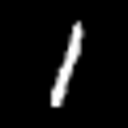
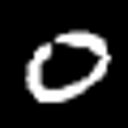
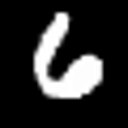
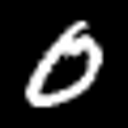
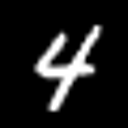
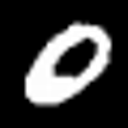
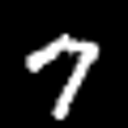
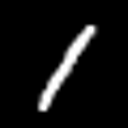

In [6]:
count = 8

def get_images_and_labels(df, ids):
    image_datas = df.loc[ids]['png']
    images = [Image.open(io.BytesIO(image_data)) for image_data in image_datas]
    labels = df.loc[ids]['value']
    return images, list(labels)

def get_some_random_images_and_labels(df, count):
    image_ids = RNG.choice(df.index.unique(), count, replace=False)
    return get_images_and_labels(df, image_ids)

train_images, train_labels = get_some_random_images_and_labels(df_train_images, count)

display_images_grid(train_images, captions=train_labels, col_count=count)

In [7]:
image = df_train_images[df_train_images.value == '5'].iloc[1]
sequences = pickle.loads(image.inner_sequences)
si_ind_dict = pickle.loads(image.inner_si_ind_dict)

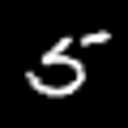

In [8]:
get_raw_image(image.name)

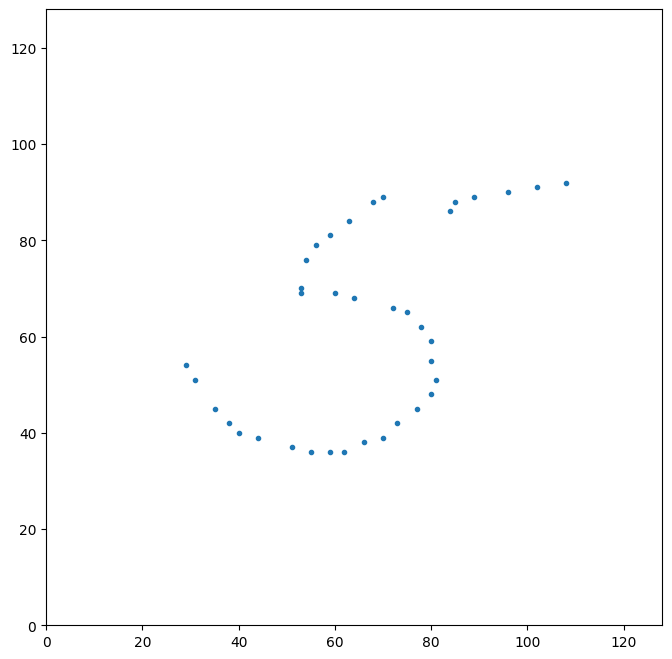

In [9]:
xy_list = get_xy_sequence(get_joint_sequence(sequences), si_ind_dict)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(xy_list[:,0], config.sample_size - xy_list[:,1], marker='.')
ax1.set_aspect('equal')
ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

In [10]:
center_pos = config.sample_size / 2
data = []

for seq in sequences:
    for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
        si_from = si_ind_dict[si_ind_from]
        si_to = si_ind_dict[si_ind_to]
        # -si_to.y + si_from.y == config.sample_size - si_to.y - (config.sample_size - si_from.y)
        data.append((
            si_from.x,
            config.sample_size - si_from.y, 
            # complex(si_to.x - si_from.x, -si_to.y + si_from.y),
            si_to.x - si_from.x,
            -si_to.y + si_from.y
        ))

data = np.array(data, dtype='f')
data[:,0] -= center_pos
data[:,1] -= center_pos
data /= config.sample_size
np.round(data[:5], decimals=2)

array([[-0.09,  0.05,  0.01,  0.05],
       [-0.08,  0.09,  0.02,  0.02],
       [-0.06,  0.12,  0.02,  0.02],
       [-0.04,  0.13,  0.03,  0.02],
       [-0.01,  0.16,  0.04,  0.03]], dtype=float32)

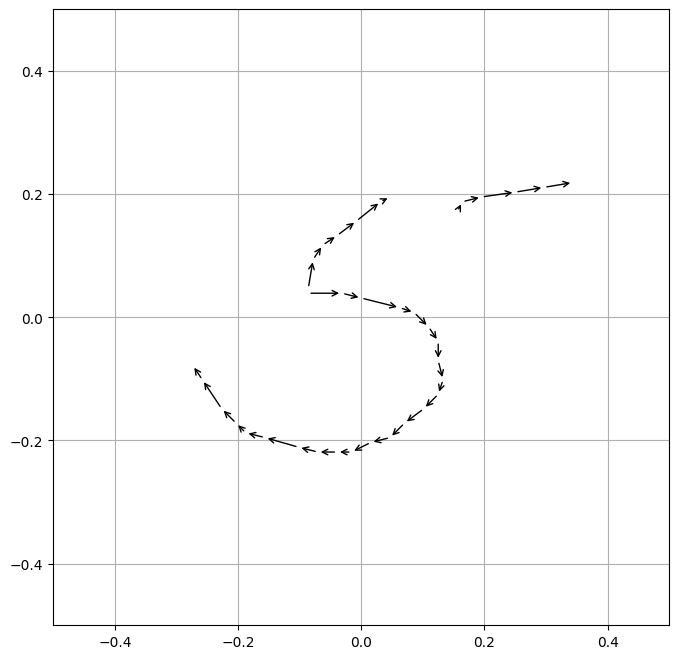

In [11]:
fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set(xlim=(-.5, .5), ylim=(-.5, .5));

for item in data:
    x_from, y_from = item[0], item[1]
    x_to, y_to = x_from + item[2], y_from + item[3]
    # x_from, y_from = item[0].real, item[1].real
    # x_to, y_to = x_from + item[2].real, y_from + item[2].imag
    ax1.annotate('', xytext=(x_from, y_from), xy=(x_to, y_to), arrowprops=dict(arrowstyle="->"))

# ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

# for seq in sequences:
#     for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
#         si_from = si_ind_dict[si_ind_from]
#         si_to = si_ind_dict[si_ind_to]
#         # x = (si_from.x + si_to.x) / 2
#         # y = config.sample_size - (si_from.y + si_to.y) / 2
#         # ax1.scatter(x, y, marker='.', color='C0')
#         ax1.annotate('', xytext=(si_from.x, config.sample_size - si_from.y), xy=(si_to.x, config.sample_size - si_to.y), arrowprops=dict(arrowstyle="->"))

# Brutefoce GP

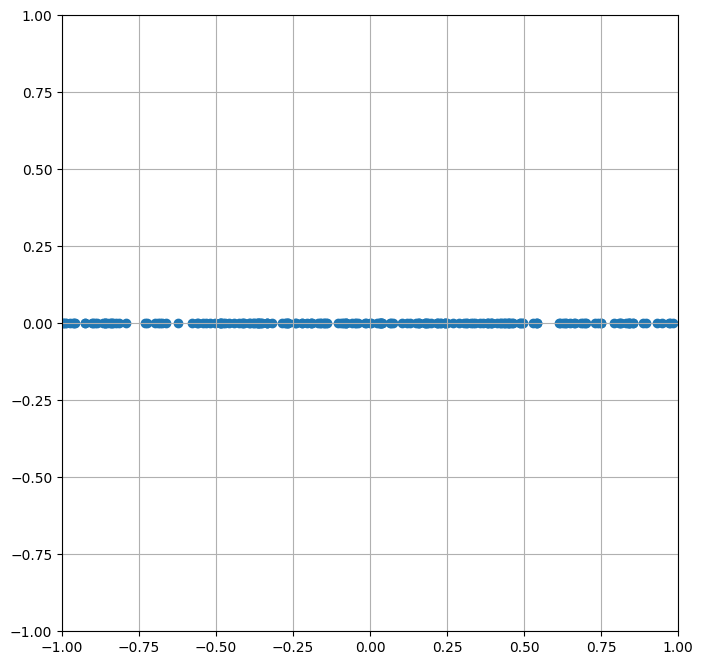

In [12]:
# Multimodal normal distribution
base_cov_mat = np.array([
    [1, 0],
    [0, 1],
])

scale_mat = np.array([[1, 0], [0, 1e-6]])
# scale_mat = np.eye(2)

def get_rot_mat(degrees):
    theta = np.deg2rad(degrees)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

rot_mat = get_rot_mat(0)
cov_mat1 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

rot_mat = get_rot_mat(130)
cov_mat2 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

cov_mat = np.zeros((cov_mat1.shape[0] + cov_mat2.shape[0], cov_mat1.shape[0] + cov_mat2.shape[0]))
base_i, base_j = 0, 0
cov_mat[base_i:base_i+cov_mat1.shape[0], base_j:base_j+cov_mat1.shape[1]] = cov_mat1
base_i, base_j = cov_mat1.shape
cov_mat[base_i:base_i+cov_mat2.shape[0], base_j:base_j+cov_mat2.shape[1]] = cov_mat2

samples_count = 300

ys = RNG.multivariate_normal(
    mean=np.zeros(cov_mat.shape[0]),
    cov=cov_mat,
    size=samples_count)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[:,0], ys[:,1], color='C0')
# ax1.scatter(ys[:,2], ys[:,3], color='C1')
#im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
# ax1.set_xlim(-.5, .5)
# ax1.set_ylim(-.5, .5)
# ax1.set_xticks(np.linspace(0, 29, 30))
# ax1.set_yticks(np.linspace(0, 29, 30))
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_aspect('equal')
ax1.grid()
# fig.colorbar(im, shrink=0.8, ax=ax1);

In [13]:
# Define the exponentiated quadratic 
def exponentiated_quadratic_kernel(xa, xb, ls=1):
    """Exponentiated quadratic with σ=1"""
    # L2 distance (Squared Euclidian)
    sq_norm = -sp.spatial.distance.cdist(xa, xb, 'sqeuclidean') / (2 * ls**2)
    return np.exp(sq_norm)

In [14]:
def linear_kernel(xa, xb, c=0, sigma_b=1, sigma_v=1):
    '''
    1) The offset "c" determines the x-coordinate of the point that all the lines
    in the posterior go though. At this point, the function will have zero
    variance (unless you add noise)
    2) The constant variance "sigma_b" determines how far from 0 the height of the
    function will be at zero. It's a little confusing, becuase it's not
    specifying that value directly, but rather putting a prior on it. It's
    equivalent to adding an uncertain offset to our model.
    3) The constant variance "sigma_v" is a prior on a slope.
    '''
    dist_func = lambda a, b: (sigma_b ** 2) + (sigma_v ** 2) * (a - c) @ (b - c)
    return sp.spatial.distance.cdist(xa, xb, dist_func)
    # return (sigma_b ** 2) + (sigma_v ** 2) * (xa - c) * (xb - c)

CPU times: user 15.2 s, sys: 14.1 ms, total: 15.2 s
Wall time: 1.39 s


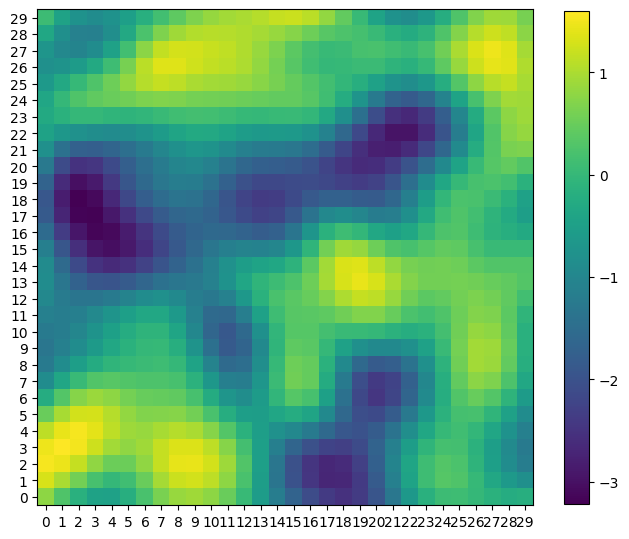

In [15]:
%%time
# Мы тут рассматриваем 2-х мерный случай: (x,y) -> значение пикселя grayscale (или on/off для BW).
# А это значит, что мы должны рассмотреть каждое сочетание из 30-и x с 30-и y. Т.е. точек будет 30х30
# Именно поэтому размер матрица ковариаций будет 900x900 и mean=np.zeros(samples_count**2)
# Если бы у нас был одномерный случай x->значение, то точек было тоже 30, а размер матрицы ковариаций был бы 30x30
# Если бы измерений было бы 3, то надо было бы рассматривать 30^3 точек = 27000

samples_count = 30
ticks = np.linspace(-.5, .5, samples_count)
base_coords = np.stack(np.meshgrid(ticks, ticks), axis=2).reshape(-1, 2)
cov_mat = exponentiated_quadratic_kernel(base_coords, base_coords, ls=0.1)
# cov_mat = linear_kernel(base_coords, base_coords, c=0, sigma_b=0.5, sigma_v=10)
cov_mat_factor_method = ['svd', 'cholesky'][0]

# ys (RV) has a samples_count**2 dimensions. So we need only 1 sample which will cover all pixels
ys = RNG.multivariate_normal(
    mean=np.zeros(samples_count**2),
    cov=cov_mat,
    method=cov_mat_factor_method)
# dist = sp.stats.multivariate_normal(
#     mean=None, 
#     cov=cov_mat,
#     allow_singular=True) # when there are many ticks (e.g. > 30), then cov_mat tends to be ill-conditioned
# ys = dist.rvs() 

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);

In [16]:
# Gaussian process posterior with noisy obeservations
def GP_noise(X1, y1, X2, kernel_func, σ_noise):
    """
    Calculate the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the noisy observations 
    (y1, X1), and the prior kernel function.
    """
    # Kernel of the noisy observations
    Σ11 = kernel_func(X1, X1) + ((σ_noise ** 2) * np.eye(len(X1)))
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2)
    # Solve
    solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance

In [17]:
kernel_func = lambda x, y: exponentiated_quadratic_kernel(x, y, ls=0.05)

data_y = np.full(len(data), 3)
μ2, Σ2 = GP_noise(data[:,:2], data_y, base_coords, kernel_func, σ_noise=0.05)
σ2 = np.sqrt(np.diag(Σ2))

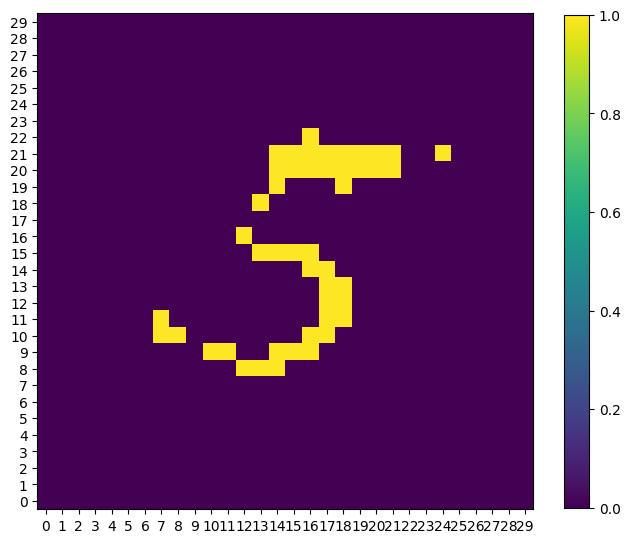

In [18]:
ys = RNG.multivariate_normal(
    mean=μ2,
    cov=Σ2,
    method=cov_mat_factor_method)
# ys = scipy.special.expit(ys)
# ys = np.where(ys > 0.5, 1, 0)
ys = np.where(ys > 2.9, 1, 0)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);